## Install Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              classification_report, accuracy_score,
                              precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Load Data 

In [3]:
df = pd.read_csv("data/HR-Employee-Attrition.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.shape
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Basic information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

## Data Cleaning

In [7]:
df.isnull().sum().sum()    #No missing data!

np.int64(0)

In [8]:
df.duplicated().sum()  #N0 duplicate data

np.int64(0)

In [9]:
# WHY we drop these columns — reasoning included
print("="*50)
print("DATA CLEANING")
print("="*50)

df_clean = df.copy()

# Drop useless columns — same value for ALL employees, no predictive power
# EmployeeCount: every row = 1 (useless)
# StandardHours: every row = 80 (useless)
# Over18: every row = 'Y' (useless)
# EmployeeNumber: just ID, no pattern
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean.drop(cols_to_drop, axis=1, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"Reason: These columns have the same value for ALL employees — zero predictive power")
print(f"\nShape before cleaning: {df.shape}")
print(f"Shape after cleaning : {df_clean.shape}")


DATA CLEANING
Dropped columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
Reason: These columns have the same value for ALL employees — zero predictive power

Shape before cleaning: (1470, 35)
Shape after cleaning : (1470, 31)


In [10]:
df_clean.shape

(1470, 31)

## Check class imbalance

In [11]:
# Check class imbalance
yes_count = df_clean[df_clean['Attrition']=='Yes'].shape[0]
no_count  = df_clean[df_clean['Attrition']=='No'].shape[0]
print(f"\nClass Imbalance Check:")
print(f"  Stayed (No)  : {no_count} ({no_count/len(df_clean)*100:.1f}%)")
print(f"  Left   (Yes) : {yes_count} ({yes_count/len(df_clean)*100:.1f}%)")
print(f"  ⚠️  Dataset is imbalanced — 'Yes' class is only 16%")
print(f"  This means model may be biased towards predicting 'No'")


Class Imbalance Check:
  Stayed (No)  : 1233 (83.9%)
  Left   (Yes) : 237 (16.1%)
  ⚠️  Dataset is imbalanced — 'Yes' class is only 16%
  This means model may be biased towards predicting 'No'


## Encoding

In [12]:
# Create a copy for encoding
df_encoded = df_clean.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Loop through all text (object) columns and convert them to numbers
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("✅ Encoding Complete: All text columns converted to numeric values.")

✅ Encoding Complete: All text columns converted to numeric values.


In [31]:
df_encoded

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,1,884,1,23,2,3,3,1,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,2,613,1,6,1,3,4,1,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,2,155,1,4,3,1,2,1,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,1,1023,2,2,3,3,4,1,...,3,4,0,17,3,2,9,6,0,8


## EDA


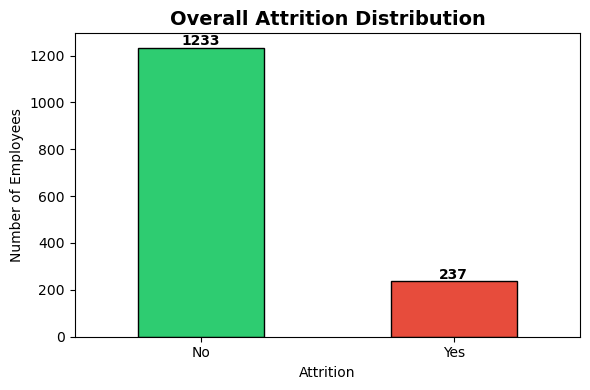

📊 INSIGHT: 84% employees stayed, only 16% left — company has moderate attrition


In [13]:
#EDA - Attrition Distribution 
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df_clean['Attrition'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Overall Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
for i, v in enumerate(df_clean['Attrition'].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: 84% employees stayed, only 16% left — company has moderate attrition")

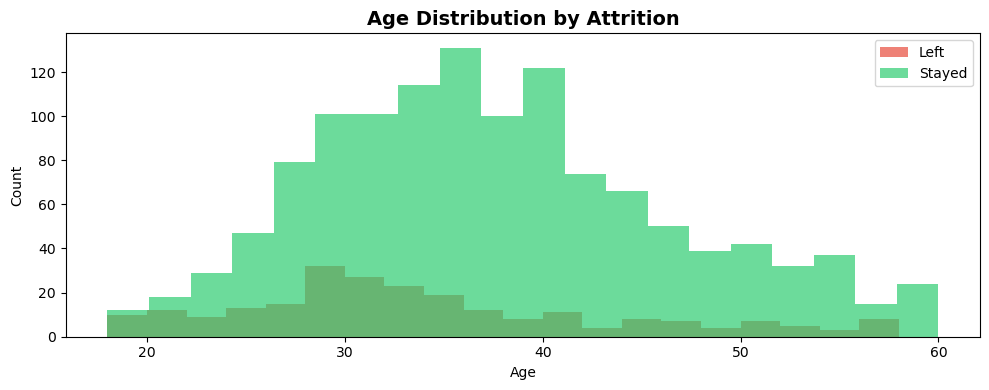

📊 INSIGHT: Young employees (25-35 age group) leave most often — they have more options and higher ambitions


In [14]:
#EDA - Age vs Attrition ───────────────────────────
plt.figure(figsize=(10, 4))
df_clean[df_clean['Attrition']=='Yes']['Age'].plot(
    kind='hist', alpha=0.7, bins=20, color='#e74c3c', label='Left')
df_clean[df_clean['Attrition']=='No']['Age'].plot(
    kind='hist', alpha=0.7, bins=20, color='#2ecc71', label='Stayed')
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plot_age_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Young employees (25-35 age group) leave most often — they have more options and higher ambitions")


<Figure size 800x500 with 0 Axes>

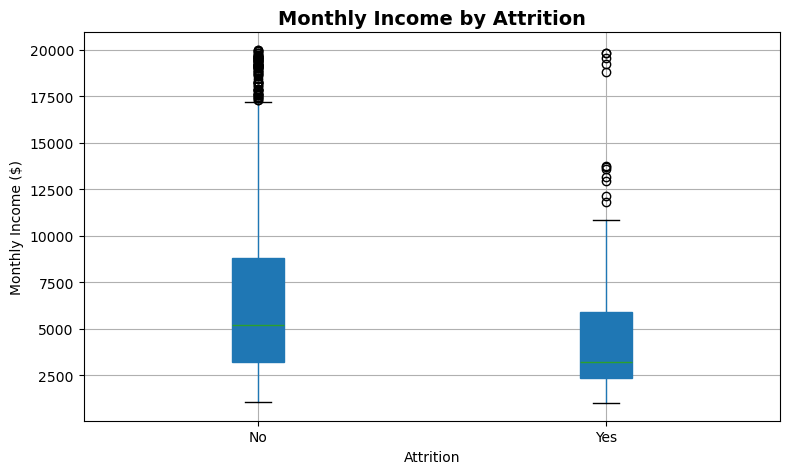

📊 INSIGHT: Employees who left had LOWER monthly income — salary dissatisfaction is a key driver


In [15]:
#EDA - Monthly Income vs Attrition ────────────────
plt.figure(figsize=(8, 5))
df_clean.boxplot(column='MonthlyIncome', by='Attrition',
                 patch_artist=True, figsize=(8, 5))
plt.title('Monthly Income by Attrition', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.savefig('plot_income_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Employees who left had LOWER monthly income — salary dissatisfaction is a key driver")


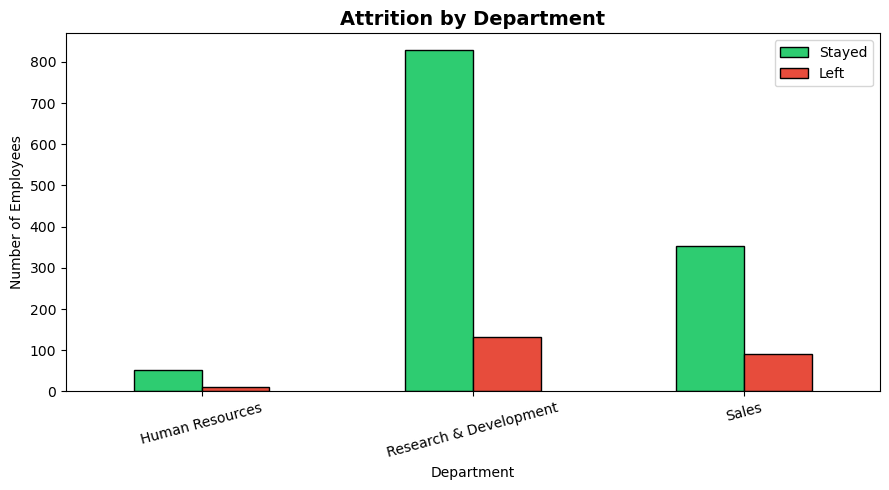

📊 INSIGHT: Sales department has the highest attrition — high pressure, target-based work causes burnout


In [16]:
#EDA - Department wise Attrition ──────────────────
dept_data = df_clean.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_data.plot(kind='bar', figsize=(9, 5), color=['#2ecc71', '#e74c3c'],
               edgecolor='black')
plt.title('Attrition by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot_dept_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Sales department has the highest attrition — high pressure, target-based work causes burnout")

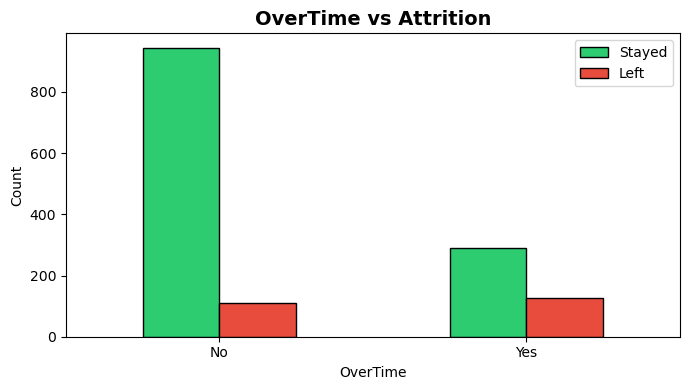

📊 INSIGHT: Employees doing OverTime leave 3x more — work-life balance is critical factor


In [17]:
#EDA - OverTime Effect ───────────────────────────
ot = df_clean.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
ot.plot(kind='bar', figsize=(7, 4), color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('OverTime vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot_overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Employees doing OverTime leave 3x more — work-life balance is critical factor")


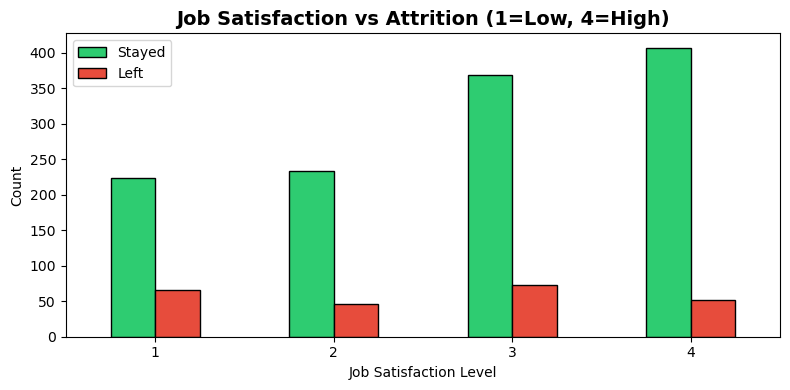

📊 INSIGHT: Low job satisfaction (Level 1) employees leave most — satisfaction directly impacts retention


In [18]:
#EDA - Job Satisfaction ──────────────────────────
js = df_clean.groupby(['JobSatisfaction', 'Attrition']).size().unstack(fill_value=0)
js.plot(kind='bar', figsize=(8, 4), color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Job Satisfaction vs Attrition (1=Low, 4=High)', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot_jobsat_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Low job satisfaction (Level 1) employees leave most — satisfaction directly impacts retention")


## Correlation

In [19]:
# Top correlations with Attrition
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
corr_matrix = df.corr(numeric_only=True)
print("\n📊 Top Features Correlated with Attrition:")
attrition_corr = corr_matrix['Attrition'].abs().sort_values(ascending=False)
print(attrition_corr[1:11])


📊 Top Features Correlated with Attrition:
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition, dtype: float64


## Train Test split

In [24]:
#Feature Engineering & Encoding ──────────────────
print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

X_train_sc, X_test_sc, _, _ = train_test_split( X_scaled, y, test_size=0.2, random_state=1, stratify=y)

print(f"Training set size : {X_train.shape[0]}")
print(f"Testing set size  : {X_test.shape[0]}")
print(f"stratify=y used   → class ratio maintained in train/test split")

FEATURE ENGINEERING
Training set size : 1176
Testing set size  : 294
stratify=y used   → class ratio maintained in train/test split


## MODEL TRAINING

In [34]:
# MULTI-MODEL TRAINING ────────────────────────────
print("="*50)
print("TRAINING 4 MODELS")
print("="*50)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=500, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, clf in models.items():
    # Use scaled data for Logistic Regression
    if name == 'Logistic Regression':
        clf.fit(X_train_sc, y_train)
        y_pred = clf.predict(X_test_sc)
        y_prob = clf.predict_proba(X_test_sc)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]

    results[name] = {
        'model'    : clf,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC Score': round(roc_auc_score(y_test, y_prob) * 100, 2),
        'y_pred'   : y_pred
    }
    print(f"✅ {name} trained")


TRAINING 4 MODELS
✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained
✅ Gradient Boosting trained


In [35]:
#Model Comparison Table ──────────────────────────
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)

comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred']}
    for name, metrics in results.items()
}).T

comparison_df = comparison_df.astype(float)
print(comparison_df.to_string())

best_model_name = comparison_df['AUC Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   AUC Score: {comparison_df.loc[best_model_name, 'AUC Score']}%")
print(f"   Accuracy : {comparison_df.loc[best_model_name, 'Accuracy']}%")



MODEL COMPARISON RESULTS
                     Accuracy  Precision  Recall  F1 Score  AUC Score
Logistic Regression     86.39      62.07   38.30     47.37      84.38
Decision Tree           78.91      29.73   23.40     26.19      67.69
Random Forest           87.07      80.00   25.53     38.71      86.86
Gradient Boosting       86.39      62.96   36.17     45.95      85.82

🏆 BEST MODEL: Random Forest
   AUC Score: 86.86%
   Accuracy : 87.07%


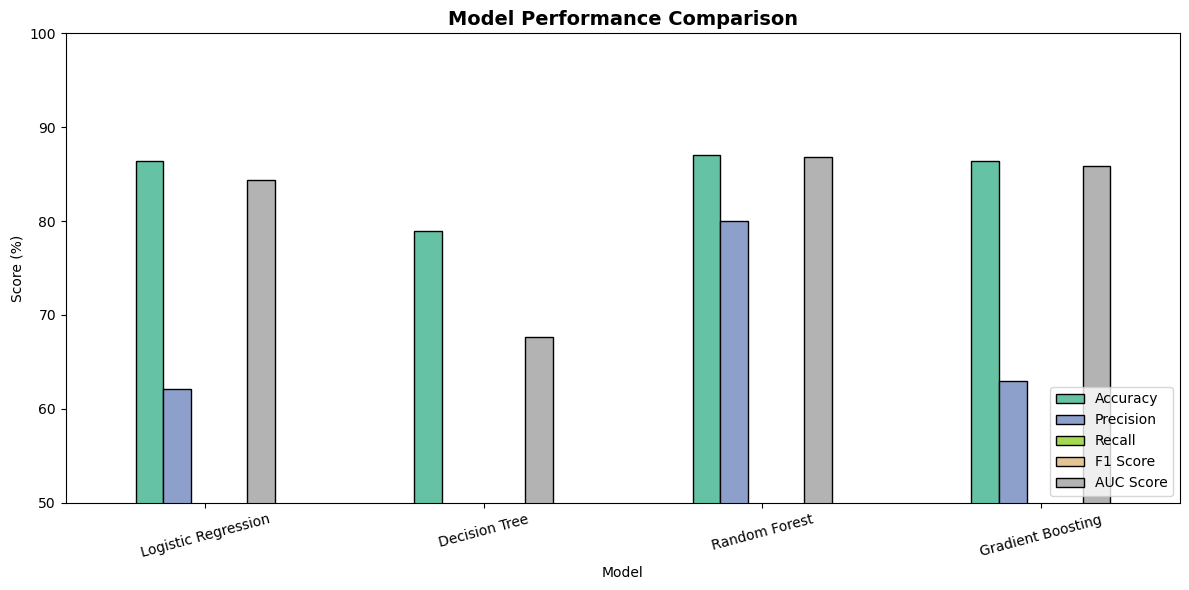

📊 INSIGHT: Random Forest and Gradient Boosting perform best — they handle non-linear data well


In [27]:
#Model Comparison Bar Chart ──────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC Score']
comparison_df[metrics_to_plot].plot(
    kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 INSIGHT: Random Forest and Gradient Boosting perform best — they handle non-linear data well")


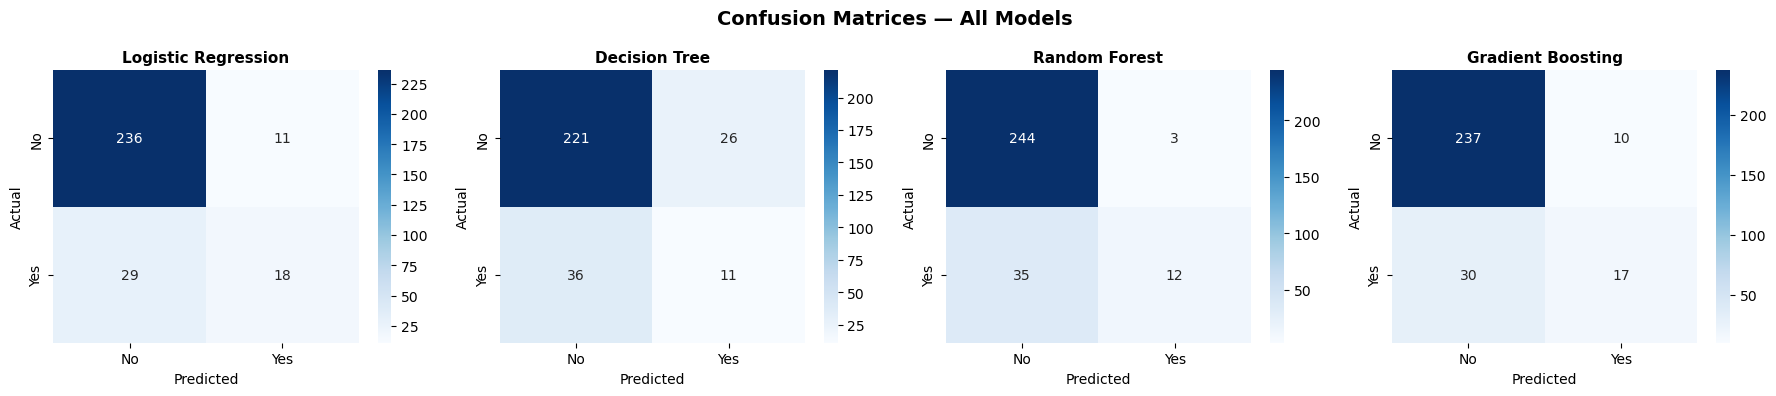

In [28]:
#Confusion Matrices for all models ───────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, metrics) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

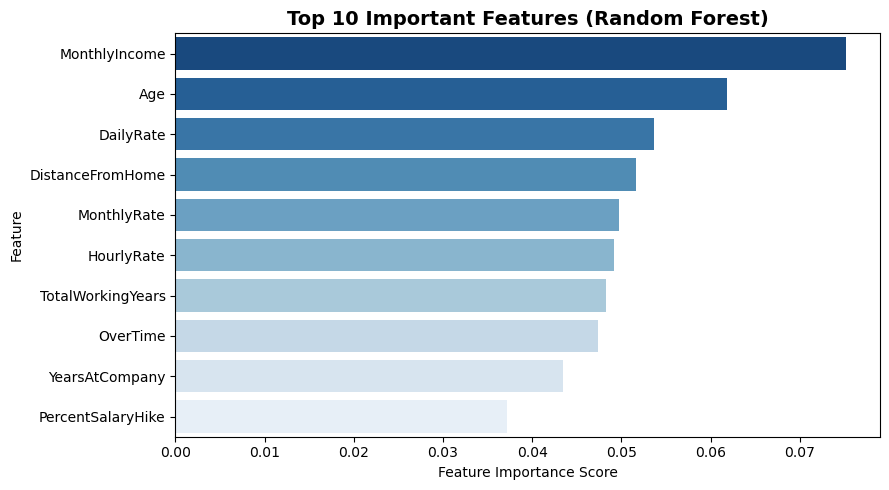


📊 Top 5 Features driving Attrition:
  MonthlyIncome                  → 0.0752
  Age                            → 0.0619
  DailyRate                      → 0.0536
  DistanceFromHome               → 0.0516
  MonthlyRate                    → 0.0497


In [29]:
#Feature Importance (Best Model) ─────────────────
best_model = results['Random Forest']['model']
fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 10 Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Top 5 Features driving Attrition:")
for i, row in fi.head(5).iterrows():
    print(f"  {row['Feature']:<30} → {row['Importance']:.4f}")

In [30]:
#Final Summary ────────────────────────────────────
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"Dataset       : IBM HR Analytics — {df.shape[0]} employees")
print(f"Attrition Rate: 16% (imbalanced dataset)")
print(f"Models Trained: {len(models)}")
print(f"\nFinal Results:")
print(comparison_df[metrics_to_plot].to_string())
print(f"\n🏆 Best Model : Random Forest")
print(f"   AUC Score  : {results['Random Forest']['AUC Score']}%")
print(f"\nKey Findings:")
print("  1. Young employees (25-35) leave most frequently")
print("  2. Low salary is the strongest attrition driver")
print("  3. OverTime employees are 3x more likely to leave")
print("  4. Sales department has highest attrition rate")
print("  5. Low job satisfaction strongly predicts attrition")
print("\n✅ All plots saved as PNG files!")
print("✅ Run 'streamlit run dashboard.py' to see interactive dashboard!")



PROJECT SUMMARY
Dataset       : IBM HR Analytics — 1470 employees
Attrition Rate: 16% (imbalanced dataset)
Models Trained: 4

Final Results:
                     Accuracy  Precision  Recall  F1 Score  AUC Score
Logistic Regression     86.39      62.07   38.30     47.37      84.38
Decision Tree           78.91      29.73   23.40     26.19      67.69
Random Forest           87.07      80.00   25.53     38.71      86.86
Gradient Boosting       86.39      62.96   36.17     45.95      85.82

🏆 Best Model : Random Forest
   AUC Score  : 86.86%

Key Findings:
  1. Young employees (25-35) leave most frequently
  2. Low salary is the strongest attrition driver
  3. OverTime employees are 3x more likely to leave
  4. Sales department has highest attrition rate
  5. Low job satisfaction strongly predicts attrition

✅ All plots saved as PNG files!
✅ Run 'streamlit run dashboard.py' to see interactive dashboard!
